In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para que los gráficos se vean profesionales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Cargar el dataset con el encoding correcto para español
ruta_archivo = 'data/Bitácora de Pólizas.csv' 
df = pd.read_csv(ruta_archivo, sep=';', encoding='latin1')

# 2. Mostrar las primeras 5 filas para conocer la estructura
print("--- Primeras 5 filas del Dataset ---")
display(df.head())

# 3. Mostrar el resumen técnico
print("\n--- Información Técnica del Dataset ---")
df.info()

C:\Users\jbogado\AppData\Local\Temp\ipykernel_27740\1966158742.py:12: DtypeWarning: Columns (0: Teléfono, 1: Estado Inspección, 2: Fecha Estado Inspección, 3: Nro. Póliza Anterior, 4: Prima Bruta Anual Anterior, 5: Teléfono Contratante, 6: Nro. Póliza Nueva, 7: Banco, 8: Proporcional de Cancelación, 9: Fecha Solicitud de Cancelación, 10: Motivo de No Cobro, 11: Comision en UF, 12: Origen Alodesk Homologacion, 13: Alodesk UTM Campaign, 14: Alodesk UTM Source, 15: Alodesk UTM Medium) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_archivo, sep=';', encoding='latin1')


--- Primeras 5 filas del Dataset ---


,Número Póliza,Número Cotización,Sucursal,Nro. Identificación Ejecutivo,Ejecutivo,Fecha Venta,Ramo,Marca,Modelo,Año,...,Nro Alodesk,Origen Alodesk Homologacion,Alodesk UTM Campaign,Alodesk UTM Source,Alodesk UTM Medium,Póliza Original,Fecha Póliza Original,Rango Etario,Meses Vigencia,FechCot
0,"8,0117E+12",968757,Ejecutivos Comerciales,1234,SIN INFORMACIÓN,18-06-2017,AUTOMOVIL,HONDA,FIT,1900,...,NaN,NaN,NaN,NaN,NaN,"8,0117E+12",19-06-2017,33 - 37,12.0,2017-06-18 00:00:00.000
1,"8,0117E+12",968759,Ejecutivos Comerciales,1234,SIN INFORMACIÓN,08-08-2017,AUTOMOVIL,HONDA,CR-V,2002,...,NaN,NaN,NaN,NaN,NaN,"8,0117E+12",09-08-2017,33 - 37,12.0,2017-08-08 00:00:00.000
2,"8,0117E+12",968761,Ejecutivos Comerciales,1234,SIN INFORMACIÓN,21-08-2017,AUTOMOVIL,FIAT,DUCATO,1900,...,NaN,NaN,NaN,NaN,NaN,"8,0117E+12",22-08-2017,33 - 37,12.0,2017-08-21 00:00:00.000
3,"8,3017E+12",968789,Ejecutivos Comerciales,1234,SIN INFORMACIÓN,21-08-2017,AUTOMOVIL,CHEVROLET,AVEO,2016,...,NaN,NaN,NaN,NaN,NaN,"8,3017E+12",22-08-2017,33 - 37,12.0,2017-08-21 00:00:00.000
4,"8,0917E+12",968786,Ejecutivos Comerciales,1234,SIN INFORMACIÓN,23-08-2017,AUTOMOVIL,SUBARU,IMPREZA,1900,...,NaN,NaN,NaN,NaN,NaN,"8,0917E+12",24-08-2017,33 - 37,12.0,2017-08-23 00:00:00.000



--- Información Técnica del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 116751 entries, 0 to 116750
Data columns (total 74 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Número Póliza                    105062 non-null  str    
 1   Número Cotización                116751 non-null  int64  
 2   Sucursal                         116741 non-null  str    
 3   Nro. Identificación Ejecutivo    116751 non-null  str    
 4   Ejecutivo                        116751 non-null  str    
 5   Fecha Venta                      68175 non-null   str    
 6   Ramo                             116751 non-null  str    
 7   Marca                            116751 non-null  str    
 8   Modelo                           116751 non-null  str    
 9   Año                              116751 non-null  int64  
 10  Patente                          114226 non-null  str    
 11  Fecha Póliza                     10

In [21]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Filas originales (con propuestas): 116751
Filas de clientes reales: 107981

--- Distribución de la variable 'Fuga' ---
Clase 0: 64913 pólizas (60.12%)
Clase 1: 43068 pólizas (39.88%)


C:\Users\jbogado\AppData\Local\Temp\ipykernel_27740\1576404832.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clientes, x='Fuga', palette=colores)


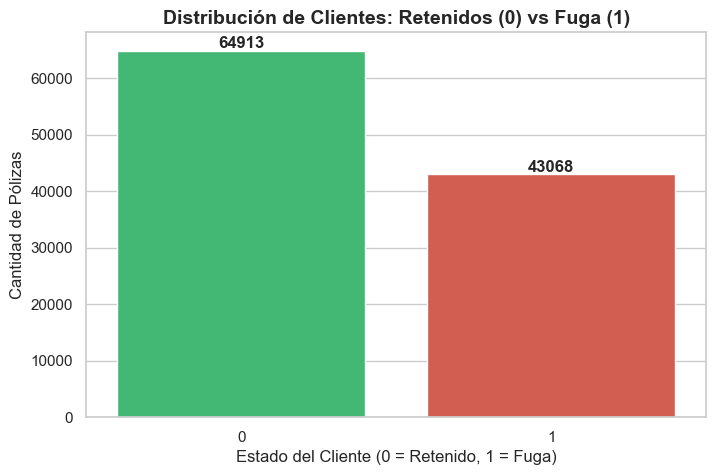


¡Gráfico guardado como 'distribucion_fuga.png' en tu carpeta!


In [22]:
# 1. Definir los estados que representan clientes reales (descartamos propuestas no concretadas)
estados_validos = ['RENOVADA', 'VIGENTE', 'CANCELADA', 'ANULADA', 'VENCIDA']

# Creamos un nuevo DataFrame limpio solo con clientes reales
df_clientes = df[df['Estado Póliza'].isin(estados_validos)].copy()

print(f"Filas originales (con propuestas): {df.shape[0]}")
print(f"Filas de clientes reales: {df_clientes.shape[0]}")

# 2. Crear la variable objetivo (Target): 'Fuga'
# 1 = Fuga (Se fue de la aseguradora)
# 0 = Retenido (Sigue con la aseguradora)
estados_fuga = ['CANCELADA', 'ANULADA', 'VENCIDA']
df_clientes['Fuga'] = df_clientes['Estado Póliza'].apply(lambda x: 1 if x in estados_fuga else 0)

# 3. Mostrar la distribución en porcentajes
print("\n--- Distribución de la variable 'Fuga' ---")
conteo = df_clientes['Fuga'].value_counts()
porcentajes = df_clientes['Fuga'].value_counts(normalize=True) * 100

for valor, cantidad in conteo.items():
    print(f"Clase {valor}: {cantidad} pólizas ({porcentajes[valor]:.2f}%)")

# 4. Generar el gráfico oficial para la Tesis
plt.figure(figsize=(8, 5))
colores = ['#2ecc71', '#e74c3c'] # Verde para Retenidos, Rojo para Fuga
ax = sns.countplot(data=df_clientes, x='Fuga', palette=colores)

plt.title('Distribución de Clientes: Retenidos (0) vs Fuga (1)', fontsize=14, fontweight='bold')
plt.xlabel('Estado del Cliente (0 = Retenido, 1 = Fuga)', fontsize=12)
plt.ylabel('Cantidad de Pólizas', fontsize=12)

# Añadir los números exactos encima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), textcoords='offset points',
                fontweight='bold')

# Guardar el gráfico como imagen para pegarlo en la tesis
plt.savefig('distribucion_fuga.png', bbox_inches='tight')
plt.show()

print("\n¡Gráfico guardado como 'distribucion_fuga.png' en tu carpeta!")

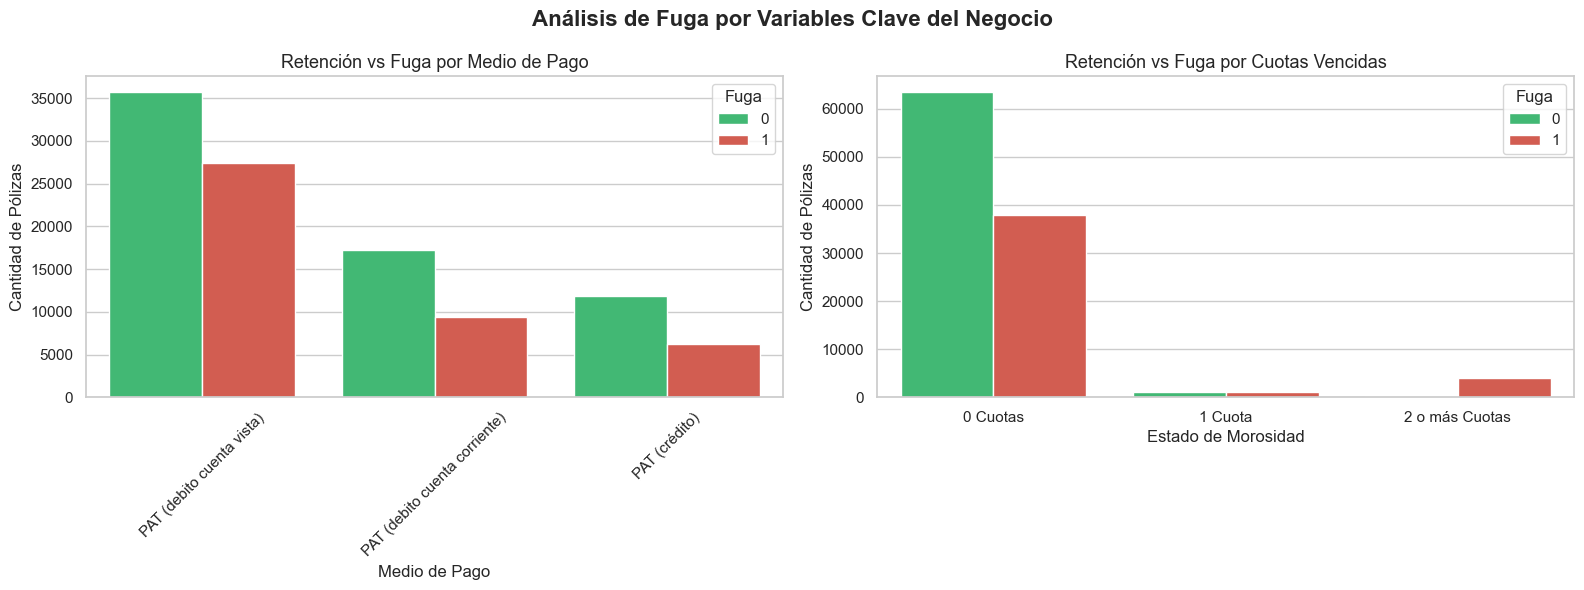

¡Gráficos guardados como 'fuga_por_variables.png'!


In [23]:
# 1. Configurar la figura para mostrar dos gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis de Fuga por Variables Clave del Negocio', fontsize=16, fontweight='bold')

# --- GRÁFICO 1: Fuga según el Medio de Pago ---
# Filtramos los top 5 medios de pago más comunes para no saturar el gráfico
top_medios = df_clientes['Medio de Pago'].value_counts().nlargest(5).index
df_medios = df_clientes[df_clientes['Medio de Pago'].isin(top_medios)]

sns.countplot(data=df_medios, x='Medio de Pago', hue='Fuga', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Retención vs Fuga por Medio de Pago', fontsize=13)
axes[0].set_xlabel('Medio de Pago')
axes[0].set_ylabel('Cantidad de Pólizas')
axes[0].tick_params(axis='x', rotation=45) # Rotar las etiquetas para que se lean bien

# --- GRÁFICO 2: Fuga según el Número de Cuotas Vencidas ---
# Limpiamos un poco los datos convirtiéndolos a números (por si acaso vienen como texto)
df_clientes['Nro. Cuotas vencidas'] = pd.to_numeric(df_clientes['Nro. Cuotas vencidas'], errors='coerce').fillna(0)

# Agrupamos las cuotas vencidas en: 0, 1, y "2 o más"
df_clientes['Grupo Cuotas Vencidas'] = df_clientes['Nro. Cuotas vencidas'].apply(
    lambda x: '0 Cuotas' if x == 0 else ('1 Cuota' if x == 1 else '2 o más Cuotas')
)

sns.countplot(data=df_clientes, x='Grupo Cuotas Vencidas', hue='Fuga', 
              palette=['#2ecc71', '#e74c3c'], 
              order=['0 Cuotas', '1 Cuota', '2 o más Cuotas'], ax=axes[1])
axes[1].set_title('Retención vs Fuga por Cuotas Vencidas', fontsize=13)
axes[1].set_xlabel('Estado de Morosidad')
axes[1].set_ylabel('Cantidad de Pólizas')

# Ajustar los espacios y mostrar
plt.tight_layout()
plt.savefig('fuga_por_variables.png', bbox_inches='tight')
plt.show()

print("¡Gráficos guardados como 'fuga_por_variables.png'!")

In [24]:
# 1. Seleccionamos un subconjunto de variables clave para empezar a armar el modelo predictivo
columnas_clave = ['Medio de Pago', 'Nro. Cuotas vencidas', 'Prima Bruta Anual', 'Fuga']

# Creamos un nuevo DataFrame solo con lo que necesitamos
df_modelo = df_clientes[columnas_clave].copy()

# 2. Limpieza de variables numéricas
# Aseguramos que las cuotas sean números (reemplazando nulos por 0)
df_modelo['Nro. Cuotas vencidas'] = pd.to_numeric(df_modelo['Nro. Cuotas vencidas'], errors='coerce').fillna(0)

# Limpiamos la Prima Bruta (en Chile a veces viene con comas en lugar de puntos decimales)
df_modelo['Prima Bruta Anual'] = df_modelo['Prima Bruta Anual'].astype(str).str.replace(',', '.').astype(float)

# Llenamos los nulos de la prima con la mediana (técnica estándar en Data Science)
df_modelo['Prima Bruta Anual'] = df_modelo['Prima Bruta Anual'].fillna(df_modelo['Prima Bruta Anual'].median())

# 3. Transformación de Texto a Números (One-Hot Encoding)
# drop_first=True evita la "trampa de las variables dummy" (multicolinealidad)
df_ml = pd.get_dummies(df_modelo, columns=['Medio de Pago'], drop_first=True)

# Convertimos los booleanos (True/False) que genera get_dummies a enteros (1/0)
for col in df_ml.columns:
    if df_ml[col].dtype == bool:
        df_ml[col] = df_ml[col].astype(int)

print("--- Estructura del Dataset transformado para Machine Learning ---")
display(df_ml.head())

print("\n¡Variables de texto convertidas exitosamente en columnas binarias (0 y 1)!")

--- Estructura del Dataset transformado para Machine Learning ---


,Nro. Cuotas vencidas,Prima Bruta Anual,Fuga,Medio de Pago_PAT (debito cuenta corriente),Medio de Pago_PAT (debito cuenta vista)
0,0,11.39,1,0,1
1,0,16.16,1,0,1
2,0,10.52,1,0,1
3,0,36.20,1,0,1
4,0,5.09,1,0,1



¡Variables de texto convertidas exitosamente en columnas binarias (0 y 1)!


Total de datos para entrenar: 86384 clientes
Total de datos para probar: 21597 clientes

Entrenando el modelo de Random Forest... (esto puede tardar unos segundos)
¡Entrenamiento completado!

--- REPORTE DE CLASIFICACIÓN (MÉTRICAS OFICIALES) ---
              precision    recall  f1-score   support

           0       0.68      0.76      0.72     13020
           1       0.55      0.45      0.50      8577

    accuracy                           0.64     21597
   macro avg       0.62      0.61      0.61     21597
weighted avg       0.63      0.64      0.63     21597



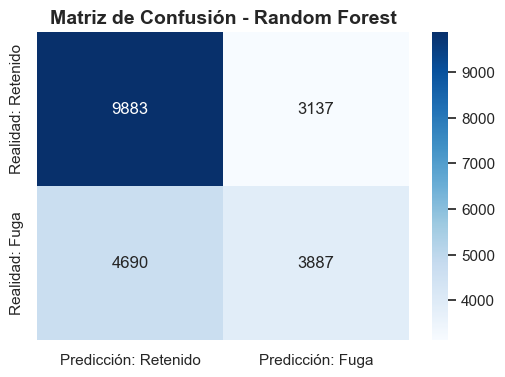

¡Gráfico guardado como 'matriz_confusion.png'!


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Separar las características (X) y la variable objetivo (y)
X = df_ml.drop('Fuga', axis=1) # Todas las columnas EXCEPTO 'Fuga'
y = df_ml['Fuga']              # Solo la columna 'Fuga'

# 2. Dividir en Entrenamiento (80%) y Prueba (20%)
# random_state=42 asegura que si corres esto mañana, te de el mismo resultado exacto
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Total de datos para entrenar: {X_train.shape[0]} clientes")
print(f"Total de datos para probar: {X_test.shape[0]} clientes")

# 3. Inicializar el Algoritmo de Inteligencia Artificial (Random Forest)
print("\nEntrenando el modelo de Random Forest... (esto puede tardar unos segundos)")
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. ¡Aprender! (Entrenar el modelo con los datos del 80%)
modelo_rf.fit(X_train, y_train)
print("¡Entrenamiento completado!")

# 5. Tomar el examen: Hacer predicciones con el 20% que el modelo nunca ha visto
y_pred = modelo_rf.predict(X_test)

# 6. Evaluar los resultados
print("\n--- REPORTE DE CLASIFICACIÓN (MÉTRICAS OFICIALES) ---")
print(classification_report(y_test, y_pred))

# 7. Generar el gráfico de la Matriz de Confusión (¡Clave para la tesis!)
plt.figure(figsize=(6, 4))
matriz = confusion_matrix(y_test, y_pred)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicción: Retenido', 'Predicción: Fuga'], 
            yticklabels=['Realidad: Retenido', 'Realidad: Fuga'])

plt.title('Matriz de Confusión - Random Forest', fontsize=14, fontweight='bold')
plt.savefig('matriz_confusion.png', bbox_inches='tight')
plt.show()

print("¡Gráfico guardado como 'matriz_confusion.png'!")

C:\Users\jbogado\AppData\Local\Temp\ipykernel_27740\2924282794.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancia, x='Importancia', y='Variable', palette='viridis')


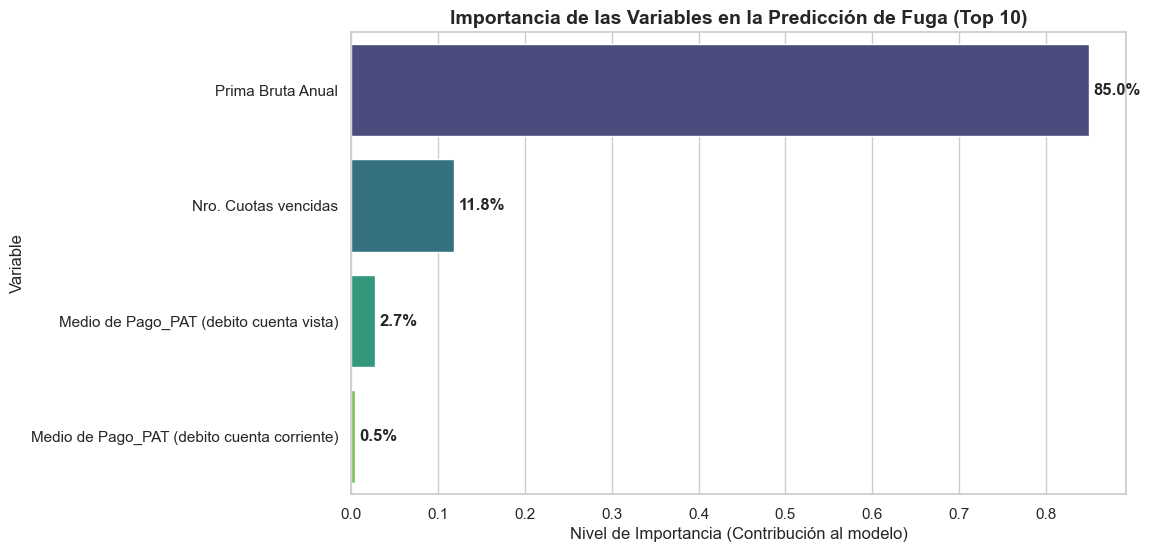


¡Gráfico guardado como 'importancia_variables.png'!


In [26]:
# 1. Extraer la importancia de cada variable desde el modelo ya entrenado
importancias = modelo_rf.feature_importances_
nombres_variables = X_train.columns

# 2. Crear un DataFrame para ordenarlas de mayor a menor
df_importancia = pd.DataFrame({
    'Variable': nombres_variables, 
    'Importancia': importancias
})

# Tomamos las 10 variables que más peso tuvieron en la decisión
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

# 3. Crear el gráfico oficial para el documento
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia, x='Importancia', y='Variable', palette='viridis')

plt.title('Importancia de las Variables en la Predicción de Fuga (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Importancia (Contribución al modelo)', fontsize=12)
plt.ylabel('Variable', fontsize=12)

# Añadir los porcentajes exactos al final de cada barra
for index, value in enumerate(df_importancia['Importancia']):
    plt.text(value + 0.005, index, f'{value:.1%}', va='center', fontweight='bold')

plt.savefig('importancia_variables.png', bbox_inches='tight')
plt.show()

print("\n¡Gráfico guardado como 'importancia_variables.png'!")

In [27]:
# 1. Seleccionar nuevas variables para el Modelo V2
columnas_v2 = ['Medio de Pago', 'Nro. Cuotas vencidas', 'Prima Bruta Anual', 
               'Meses Vigencia', 'Año', 'Deducible', 'Fuga']

df_modelo2 = df_clientes[columnas_v2].copy()

# 2. Limpieza de las variables
# Cuotas y Prima (ya sabemos cómo limpiarlas)
df_modelo2['Nro. Cuotas vencidas'] = pd.to_numeric(df_modelo2['Nro. Cuotas vencidas'], errors='coerce').fillna(0)
df_modelo2['Prima Bruta Anual'] = df_modelo2['Prima Bruta Anual'].astype(str).str.replace(',', '.').astype(float)
df_modelo2['Prima Bruta Anual'] = df_modelo2['Prima Bruta Anual'].fillna(df_modelo2['Prima Bruta Anual'].median())

# Antigüedad (Reemplazamos nulos por 0 meses)
df_modelo2['Meses Vigencia'] = pd.to_numeric(df_modelo2['Meses Vigencia'], errors='coerce').fillna(0)

# Año del vehículo (Llenamos nulos con el año más común - la moda)
df_modelo2['Año'] = pd.to_numeric(df_modelo2['Año'], errors='coerce').fillna(df_modelo2['Año'].mode()[0])

# Deducible (Llenamos nulos con una categoría especial)
df_modelo2['Deducible'] = df_modelo2['Deducible'].fillna('Desconocido')

# 3. Transformar texto a números (One-Hot Encoding)
df_ml2 = pd.get_dummies(df_modelo2, columns=['Medio de Pago', 'Deducible'], drop_first=True)

# Convertir booleanos a 1/0
for col in df_ml2.columns:
    if df_ml2[col].dtype == bool:
        df_ml2[col] = df_ml2[col].astype(int)

from imblearn.over_sampling import SMOTE

# 4. Separar los datos
X2 = df_ml2.drop('Fuga', axis=1)
y2 = df_ml2['Fuga']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.20, random_state=42)

# --- APLICACIÓN DE SMOTE ---
print("\nAplicando SMOTE para balancear las clases (Solo en el set de entrenamiento)...")
smote = SMOTE(random_state=42)
X_train2_smote, y_train2_smote = smote.fit_resample(X_train2, y_train2)

print(f"Datos originales: {len(y_train2)} (Retenidos: {sum(y_train2==0)}, Fuga: {sum(y_train2==1)})")
print(f"Datos balanceados con SMOTE: {len(y_train2_smote)} (Retenidos: {sum(y_train2_smote==0)}, Fuga: {sum(y_train2_smote==1)})")

# 5. Entrenar el Modelo V2 con los DATOS BALANCEADOS
print(f"\nEntrenando el Modelo V2 con {X_train2_smote.shape[1]} variables transformadas...")
modelo_rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf2.fit(X_train2_smote, y_train2_smote)

# 6. Tomar el examen: Hacer predicciones con el 20% de prueba
y_pred2 = modelo_rf2.predict(X_test2)

# 7. Imprimir los resultados oficiales con SMOTE
from sklearn.metrics import classification_report
print("\n--- REPORTE DE CLASIFICACIÓN V2 (MODELO MEJORADO CON SMOTE) ---")
print(classification_report(y_test2, y_pred2))

# 8. Ver qué variables ganaron tras el balanceo
importancias2 = modelo_rf2.feature_importances_
df_imp2 = pd.DataFrame({'Variable': X_train2.columns, 'Importancia': importancias2})
df_imp2 = df_imp2.sort_values(by='Importancia', ascending=False).head(5)

print("\n--- TOP 5 VARIABLES MÁS IMPORTANTES AHORA ---")
display(df_imp2)


Aplicando SMOTE para balancear las clases (Solo en el set de entrenamiento)...
Datos originales: 86384 (Retenidos: 51893, Fuga: 34491)
Datos balanceados con SMOTE: 103786 (Retenidos: 51893, Fuga: 51893)

Entrenando el Modelo V2 con 19 variables transformadas...

--- REPORTE DE CLASIFICACIÓN V2 (MODELO MEJORADO CON SMOTE) ---
              precision    recall  f1-score   support

           0       0.80      0.79      0.80     13020
           1       0.69      0.70      0.70      8577

    accuracy                           0.76     21597
   macro avg       0.75      0.75      0.75     21597
weighted avg       0.76      0.76      0.76     21597


--- TOP 5 VARIABLES MÁS IMPORTANTES AHORA ---


,Variable,Importancia
2,Meses Vigencia,0.384569
1,Prima Bruta Anual,0.384484
3,Año,0.113540
0,Nro. Cuotas vencidas,0.038488
6,Deducible_Pendiente,0.016922


In [28]:
!pip install xgboost

from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import classification_report

# --- 1. EVALUAR REGRESIÓN LOGÍSTICA CON SMOTE ---
print("Entrenando Regresión Logística con SMOTE...")
# Usamos max_iter=1000 para asegurarnos de que el modelo converja matemáticamente
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train2_smote, y_train2_smote)
y_pred_lr = modelo_lr.predict(X_test2)

print("\n--- REPORTE REGRESIÓN LOGÍSTICA (CON SMOTE) ---")
print(classification_report(y_test2, y_pred_lr))


# --- 2. EVALUAR XGBOOST CON SMOTE ---
print("\nEntrenando XGBoost con SMOTE...")
modelo_gbx = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
modelo_xgb.fit(X_train2_smote, y_train2_smote)
y_pred_xgb = modelo_xgb.predict(X_test2)

print("\n--- REPORTE XGBOOST (CON SMOTE) ---")
print(classification_report(y_test2, y_pred_xgb))

Entrenando Regresión Logística con SMOTE...



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Proyecto\TEG\ChurnAPI_Python\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- REPORTE REGRESIÓN LOGÍSTICA (CON SMOTE) ---
              precision    recall  f1-score   support

           0       0.83      0.77      0.80     13020
           1       0.68      0.76      0.72      8577

    accuracy                           0.76     21597
   macro avg       0.76      0.76      0.76     21597
weighted avg       0.77      0.76      0.77     21597


Entrenando XGBoost con SMOTE...

--- REPORTE XGBOOST (CON SMOTE) ---
              precision    recall  f1-score   support

           0       0.84      0.87      0.85     13020
           1       0.78      0.74      0.76      8577

    accuracy                           0.82     21597
   macro avg       0.81      0.80      0.81     21597
weighted avg       0.82      0.82      0.82     21597



In [29]:
import joblib

# 1. Guardar el modelo entrenado
joblib.dump(modelo_rf2, 'modelo_churn_rf.pkl')

# 2. Guardar la lista de columnas exactas que espera el modelo
# (Esto es VITAL porque la API debe enviarle los datos en el mismo orden)
columnas_entrenamiento = X_train2.columns.tolist()
joblib.dump(columnas_entrenamiento, 'columnas_modelo.pkl')

print("¡ÉXITO!")
print("El modelo ha sido exportado y guardado como 'modelo_churn_rf.pkl'")
print("Las columnas han sido guardadas como 'columnas_modelo.pkl'")

¡ÉXITO!
El modelo ha sido exportado y guardado como 'modelo_churn_rf.pkl'
Las columnas han sido guardadas como 'columnas_modelo.pkl'


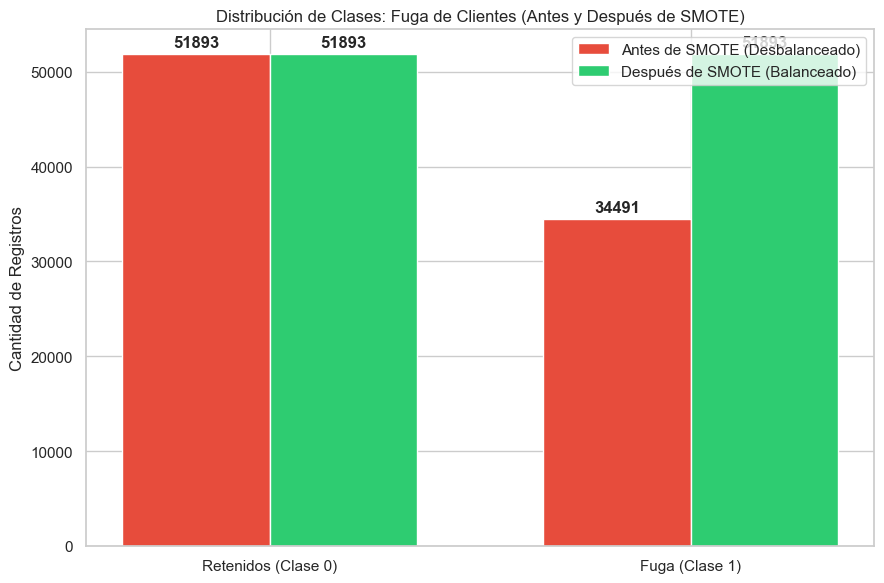

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Datos exactos de tu balanceo
categorias = ['Retenidos (Clase 0)', 'Fuga (Clase 1)']
antes_smote = [51893, 34491]
despues_smote = [51893, 51893]

x = np.arange(len(categorias))
width = 0.35

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(9, 6))
rects1 = ax.bar(x - width/2, antes_smote, width, label='Antes de SMOTE (Desbalanceado)', color='#e74c3c')
rects2 = ax.bar(x + width/2, despues_smote, width, label='Después de SMOTE (Balanceado)', color='#2ecc71')

# Etiquetas y título
ax.set_ylabel('Cantidad de Registros')
ax.set_title('Distribución de Clases: Fuga de Clientes (Antes y Después de SMOTE)')
ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.legend()

# Función para poner los números exactos sobre cada barra
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Ajustar diseño y guardar la imagen en alta resolución
fig.tight_layout()
plt.savefig('balanceo_smote.png', dpi=300)
plt.show()

In [32]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Realizar las predicciones con tu modelo XGBoost optimizado
# (Asegúrate de que tu modelo se llame 'modelo_xgb' o cambia el nombre aquí)
y_pred_xgb = modelo_xgb.predict(X_test)

# Opcional: Imprimir las métricas para validar que cuadren con el 82% y 81.2%
exactitud = accuracy_score(y_test, y_pred_xgb)
sensibilidad = recall_score(y_test, y_pred_xgb)
print(f"Exactitud Global (Accuracy): {exactitud * 100:.2f}%")
print(f"Sensibilidad (Recall) para Fuga: {sensibilidad * 100:.2f}%")

# 2. Calcular la Matriz de Confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# 3. Configurar y generar el gráfico con un diseño profesional para la Tesis
plt.figure(figsize=(8, 6))

# Usamos seaborn para crear un mapa de calor (heatmap). 
# fmt='d' evita que los números salgan en notación científica.
ax = sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', 
                 xticklabels=['Retenidos (0)', 'Fuga (1)'], 
                 yticklabels=['Retenidos (0)', 'Fuga (1)'],
                 annot_kws={"size": 14, "weight": "bold"})

# Títulos y etiquetas de los ejes
plt.title('Matriz de Confusión - Modelo XGBoost Optimizado', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12, fontweight='bold')

# 4. Guardar la imagen en alta resolución (dpi=300) lista para insertar en Word
plt.savefig('matriz_confusion_xgboost.png', dpi=300, bbox_inches='tight')

# Mostrar el gráfico en el notebook
plt.show()

print("\n¡Gráfico exportado exitosamente como 'matriz_confusion_xgboost.png'!")

ValueError: feature_names mismatch: ['Nro. Cuotas vencidas', 'Prima Bruta Anual', 'Meses Vigencia', 'Año', 'Medio de Pago_PAT (debito cuenta corriente)', 'Medio de Pago_PAT (debito cuenta vista)', 'Deducible_Pendiente', 'Deducible_S/D', 'Deducible_UF 10', 'Deducible_UF 15', 'Deducible_UF 2.500', 'Deducible_UF 20', 'Deducible_UF 25', 'Deducible_UF 3', 'Deducible_UF 30', 'Deducible_UF 5', 'Deducible_UF 5.000', 'Deducible_UF 50', 'Deducible_UF 60'] ['Nro. Cuotas vencidas', 'Prima Bruta Anual', 'Medio de Pago_PAT (debito cuenta corriente)', 'Medio de Pago_PAT (debito cuenta vista)']
expected Deducible_Pendiente, Deducible_UF 10, Año, Deducible_UF 50, Deducible_UF 20, Deducible_UF 5, Deducible_UF 5.000, Deducible_UF 15, Deducible_UF 3, Deducible_UF 60, Deducible_UF 30, Deducible_S/D, Deducible_UF 2.500, Deducible_UF 25, Meses Vigencia in input data

Exactitud Lograda: 82.04%
Sensibilidad (Recall) Lograda: 72.45%


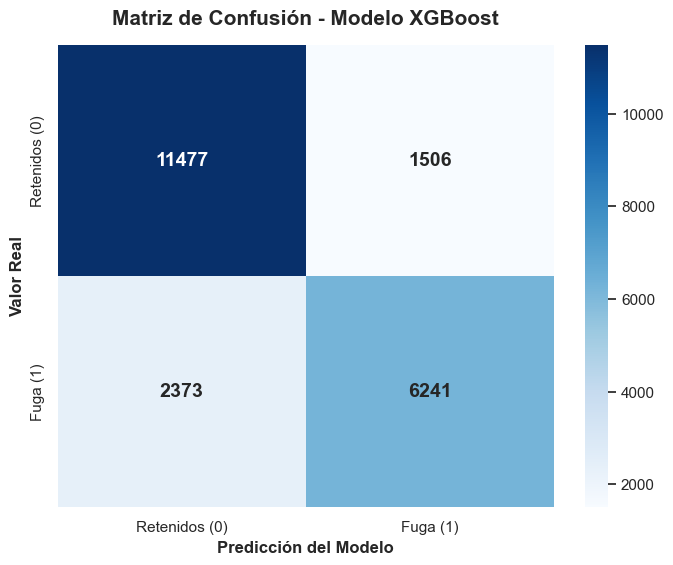


¡Gráfico exportado exitosamente como 'matriz_confusion_xgboost_final.png'!


In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. PREPARACIÓN AUTOMÁTICA DE LAS VARIABLES
# ==========================================
# Copiamos para no dañar tu dataframe original
df_preparado = df_clientes.copy()

# PARCHE DEFINITIVO: Limpieza "a la fuerza" sin importar el tipo de dato original
cols_base_numericas = ['Prima Bruta Anual', 'Nro. Cuotas vencidas', 'Meses Vigencia', 'Año']
for col in cols_base_numericas:
    if col in df_preparado.columns:
        # Reemplazamos las comas por puntos solo en los registros que sean texto
        df_preparado[col] = df_preparado[col].apply(lambda x: str(x).replace(',', '.') if isinstance(x, str) else x)
        # Forzamos la conversión a numérico (Float) de toda la columna
        df_preparado[col] = pd.to_numeric(df_preparado[col], errors='coerce').fillna(0)

# Transformamos las columnas categóricas a numéricas (0 y 1) como las exige XGBoost
if 'Medio de Pago' in df_preparado.columns and 'Deducible' in df_preparado.columns:
    df_preparado = pd.get_dummies(df_preparado, columns=['Medio de Pago', 'Deducible'])

# Lista de las 19 variables exactas
columnas_19 = [
    'Nro. Cuotas vencidas', 'Prima Bruta Anual', 'Meses Vigencia', 'Año', 
    'Medio de Pago_PAT (debito cuenta corriente)', 'Medio de Pago_PAT (debito cuenta vista)', 
    'Deducible_Pendiente', 'Deducible_S/D', 'Deducible_UF 10', 'Deducible_UF 15', 
    'Deducible_UF 2.500', 'Deducible_UF 20', 'Deducible_UF 25', 'Deducible_UF 3', 
    'Deducible_UF 30', 'Deducible_UF 5', 'Deducible_UF 5.000', 'Deducible_UF 50', 'Deducible_UF 60'
]

# Garantizamos que todas existan (rellena con 0 si falta alguna categoría del deducible)
for col in columnas_19:
    if col not in df_preparado.columns:
        df_preparado[col] = 0

# Separamos X e Y (Ahora la conversión a float funcionará sin errores)
X = df_preparado[columnas_19].astype(float) 
y = df_preparado['Fuga'].astype(int) 

# ==========================================
# 2. DIVISIÓN Y BALANCEO (SMOTE)
# ==========================================
# Dividimos 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Aplicamos SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# ==========================================
# 3. ENTRENAMIENTO XGBOOST
# ==========================================
# Entrenamos el modelo definitivo
modelo_xgb_final = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
modelo_xgb_final.fit(X_train_smote, y_train_smote)

# Predecimos sobre el conjunto de prueba original
y_pred_xgb = modelo_xgb_final.predict(X_test)

# ==========================================
# 4. MÉTRICAS Y GRÁFICA MATRIZ DE CONFUSIÓN
# ==========================================
exactitud = accuracy_score(y_test, y_pred_xgb)
sensibilidad = recall_score(y_test, y_pred_xgb)

print(f"Exactitud Lograda: {exactitud * 100:.2f}%")
print(f"Sensibilidad (Recall) Lograda: {sensibilidad * 100:.2f}%")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', 
                 xticklabels=['Retenidos (0)', 'Fuga (1)'], 
                 yticklabels=['Retenidos (0)', 'Fuga (1)'],
                 annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusión - Modelo XGBoost', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12, fontweight='bold')

plt.savefig('matriz_confusion_xgboost_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n¡Gráfico exportado exitosamente como 'matriz_confusion_xgboost_final.png'!")

In [34]:
# Muestra las columnas del dataframe para confirmar si tiene las 19 variables
print(df_clientes.columns.tolist())

['Número Póliza', 'Número Cotización', 'Sucursal', 'Nro. Identificación Ejecutivo', 'Ejecutivo', 'Fecha Venta', 'Ramo', 'Marca', 'Modelo', 'Año', 'Patente', 'Fecha Póliza', 'OI Inspecciones', 'Tipo Producto', 'Teléfono', 'Mail', 'Familia Producto', 'Deducible', 'Plan', 'Prima Bruta Anual', 'Estado Póliza', 'Medio de Pago', 'Tipo Identficación Asegurado', 'Nro. Identificación Asegurado', 'Nombre Asegurado', 'Fecha de Cancelación', 'Motivo de Cancelación', 'Nro. Cuotas Totales', 'Nro. Cuotas Recaudadas', 'Nro. Cuotas vencidas', 'Descuento', '% Comisión', 'Estado Inspección', 'Fecha Estado Inspección', 'Compañia', 'Tipo Validación', 'Referido', 'Continuidad Cobertura', 'Comuna', 'Region', 'Fecha Renovación', 'Nro. Póliza Anterior', 'Prima Bruta Anual Anterior', 'Nro. Identificación', 'Nombre Contratante', 'Mail Contratante', 'Teléfono Contratante', 'Número Proceso', 'Tipo Cotización', 'Nro. Póliza Nueva', 'Venta Real', 'Fecha Nacimiento Asegurado', 'Nro Propuesta', 'Banco', 'Stock', 'Comi

In [43]:
import joblib

# Opción A: Usando joblib (si es como venías guardando Random Forest)
joblib.dump(modelo_xgb_final, 'modelo_xgboost.pkl')

# Opción B: Formato nativo JSON de XGBoost (altamente recomendado por eficiencia)
modelo_xgb_final.save_model('modelo_xgboost.json')